# Advanced Regime Detection Comparison

Compares three regime detection approaches:
1. **Rule-based**: ADX/ATR thresholds (existing baseline)
2. **HMM**: Hidden Markov Model with Gaussian emissions
3. **PCA + k-means**: Unsupervised clustering on PCA-reduced features

## Objectives
1. Load SPY daily data (2015-2024)
2. Generate technical features for regime detection
3. Run all three detectors on same data
4. Compare regime distributions, transition matrices
5. Visualize regime time series side-by-side
6. Identify periods with different regime classifications

## Setup & Configuration

In [1]:
import yfinance as yf

CONFIG = {
    "data": {
        "ticker": "SPY",
        "start": "2015-01-01",
        "end": "2024-12-31",
    },
    "hmm": {
        "n_states": 4,
        "covariance_type": "diag",
        "max_iter": 200,
        "random_state": 42,
    },
    "pca_kmeans": {
        "k_range": (3, 6),
        "variance_threshold": 0.95,
        "random_state": 42,
    },
    "features": {
        "rsi_period": 14,
        "macd_fast": 12,
        "macd_slow": 26,
        "macd_signal": 9,
        "atr_period": 14,
        "volatility_window": 20,
    },
}

In [2]:
import sys
from pathlib import Path

# Add src to Python path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

## 1. Load SPY Data

In [3]:
# Download SPY data
ticker = CONFIG["data"]["ticker"]
start = CONFIG["data"]["start"]
end = CONFIG["data"]["end"]

print(f"Downloading {ticker} from {start} to {end}...")
df = yf.download(ticker, start=start, end=end, auto_adjust=True)

# Handle multi-level columns from yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Standardize column names
df = df.rename(
    columns={
        "High": "High",
        "Low": "Low",
        "Close": "Close",
        "Open": "Open",
        "Volume": "Volume",
        "Adj Close": "Adj_Close",
    }
)

df.index.name = "date"
df = df.sort_index()
df = df.dropna(subset=["High", "Low", "Close"])

print(f"Data loaded: {len(df)} bars")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

[*********************100%***********************]  1 of 1 completed

Data loaded: 2515 bars
Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
date,,,,,
2015-01-02,170.124939,171.325753,169.089763,170.911683,121465900
2015-01-05,167.052612,169.247181,166.746204,169.081555,169632600
2015-01-06,165.479141,167.880745,164.684120,167.359012,209151400
2015-01-07,167.541153,167.880694,166.356918,166.804108,125346700
2015-01-08,170.514206,170.729531,168.932466,168.949020,147217800


## 2. Feature Engineering

In [4]:
def generate_regime_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Generate technical features for regime detection.

    Features:
    - RSI (14-day)
    - MACD (12, 26, 9)
    - Returns (1-day, 5-day, 20-day)
    - Volatility (20-day rolling std)
    - ATR (14-day)
    - ADX (14-day)
    """
    import pandas_ta as ta

    features = pd.DataFrame(index=df.index)

    # Price-based features
    features["rsi"] = ta.rsi(df["Close"], length=config["features"]["rsi_period"])

    # MACD
    macd = ta.macd(
        df["Close"],
        fast=config["features"]["macd_fast"],
        slow=config["features"]["macd_slow"],
        signal=config["features"]["macd_signal"],
    )
    # pandas-ta column format: MACD_{fast}_{slow}_{signal}
    macd_col = f"MACD_{config['features']['macd_fast']}_{config['features']['macd_slow']}_{config['features']['macd_signal']}"
    features["macd"] = macd[macd_col]
    features["macd_signal"] = macd[macd_col.replace("MACD_", "MACDs_")]
    features["macd_hist"] = macd[macd_col.replace("MACD_", "MACDh_")]

    # Returns
    features["return_1d"] = df["Close"].pct_change()
    features["return_5d"] = df["Close"].pct_change(5)
    features["return_20d"] = df["Close"].pct_change(20)

    # Volatility
    features["volatility_20d"] = (
        features["return_1d"].rolling(config["features"]["volatility_window"]).std()
    )

    # ATR
    features["atr"] = ta.atr(
        df["High"], df["Low"], df["Close"], length=config["features"]["atr_period"]
    )

    # ATR ratio (normalized by close)
    features["atr_ratio"] = features["atr"] / df["Close"]

    # ADX
    adx = ta.adx(df["High"], df["Low"], df["Close"], length=14)
    features["adx"] = adx["ADX_14"]

    # Min/max range
    features["range"] = (df["High"] - df["Low"]) / df["Close"]

    # Drop NaN rows
    features = features.dropna()

    return features


# Generate features
print("Generating regime features...")
features = generate_regime_features(df, CONFIG)
print(f"Features created: {features.shape}")
print(f"Feature columns: {features.columns.tolist()}")
features.head()

Generating regime features...


Features created: (2482, 12)
Feature columns: ['rsi', 'macd', 'macd_signal', 'macd_hist', 'return_1d', 'return_5d', 'return_20d', 'volatility_20d', 'atr', 'atr_ratio', 'adx', 'range']


,rsi,macd,macd_signal,macd_hist,return_1d,return_5d,return_20d,volatility_20d,atr,atr_ratio,adx,range
date,,,,,,,,,,,,
2015-02-20,52.055914,1.811960,1.287305,0.524656,0.006001,0.011105,0.024939,0.008443,1.952163,0.011159,30.913412,0.012308
2015-02-23,51.976144,1.877935,1.405431,0.472504,-0.000142,0.006817,0.030444,0.008301,1.857676,0.010621,28.969317,0.003456
2015-02-24,53.513377,1.947859,1.513916,0.433942,0.002841,0.008091,0.030956,0.008305,1.801293,0.010269,27.567761,0.006090
2015-02-25,52.965494,1.968551,1.604843,0.363708,-0.000850,0.007139,0.043849,0.007578,1.732965,0.009888,26.357556,0.004820
2015-02-26,52.166797,1.945814,1.673037,0.272777,-0.001181,0.006667,0.056161,0.006769,1.671885,0.009551,24.889667,0.005015


## 3. Rule-based Regime Detector (Baseline)

In [5]:
from src.indicators.regime_detector import RegimeDetector

# Run rule-based detector
rule_detector = RegimeDetector()
rule_regimes = rule_detector.classify(df)

# Convert enum to string
rule_regimes_str = rule_regimes.apply(lambda x: x.value)

print(f"Rule-based regimes detected: {len(rule_regimes)} bars")
print(f"Regime distribution:\n{rule_regimes_str.value_counts()}")

Rule-based regimes detected: 2515 bars
Regime distribution:
regime
Trending      1177
Ranging        938
Volatile       300
Transition     100
Name: count, dtype: int64


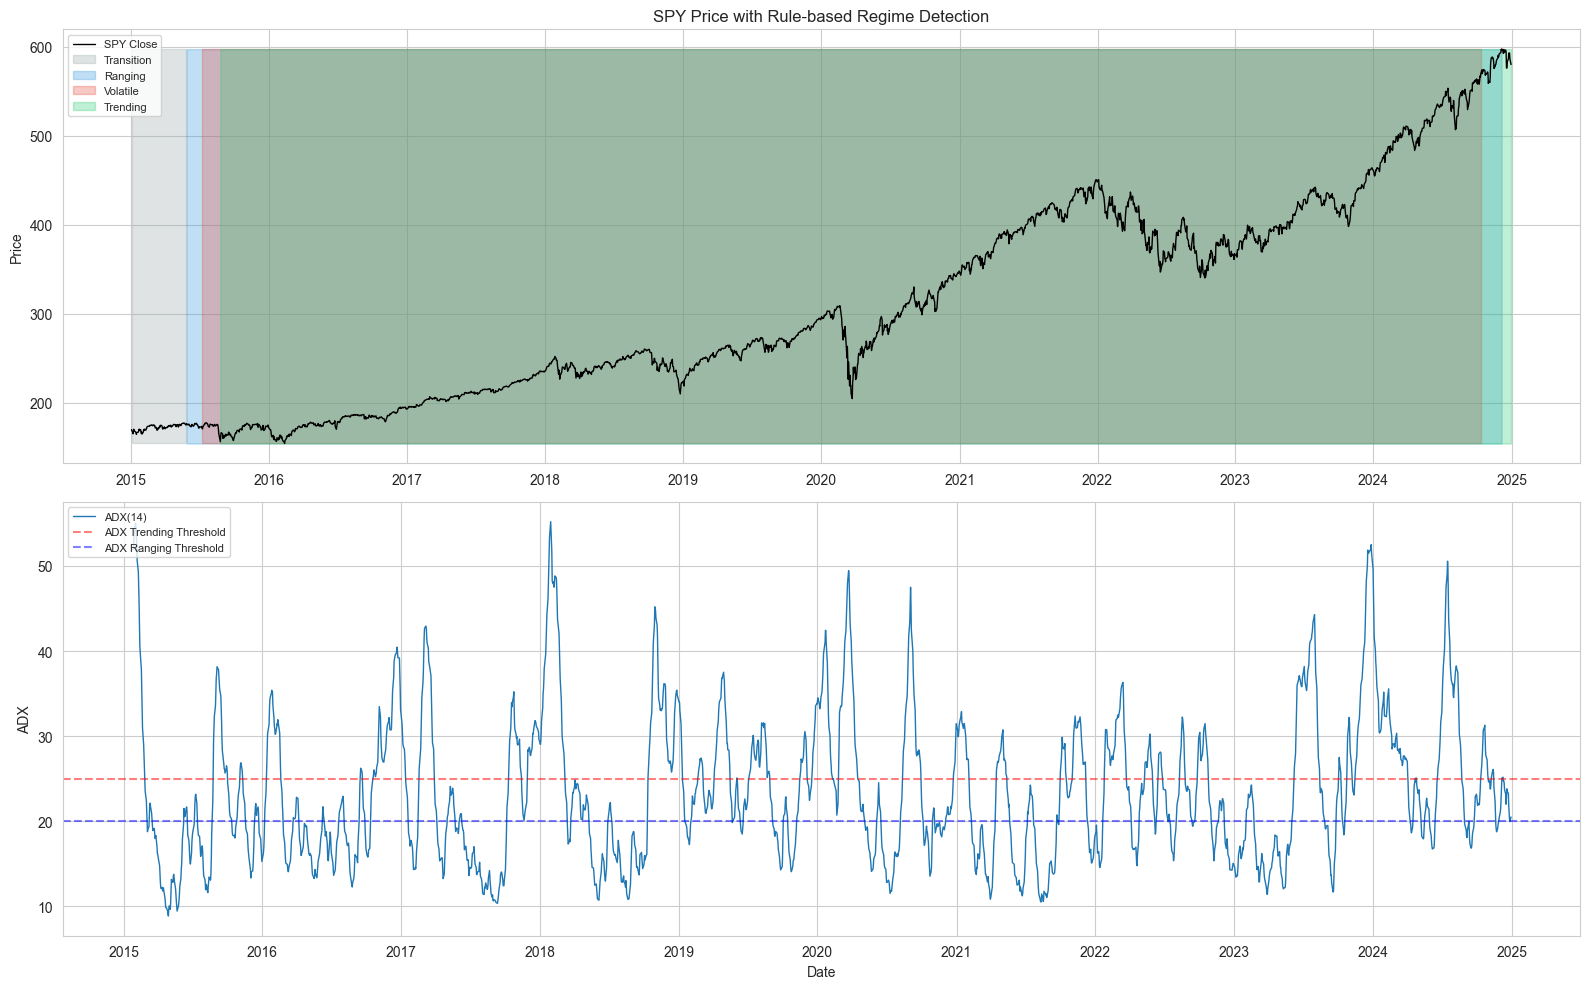

In [6]:
# Visualize rule-based regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Price with regime bands
ax1 = axes[0]
ax1.plot(df.index, df["Close"], label="SPY Close", linewidth=1, color="black")

# Color background by regime
regime_colors = {
    "Trending": "#2ecc71",
    "Ranging": "#3498db",
    "Volatile": "#e74c3c",
    "Transition": "#95a5a6",
}

for regime in rule_regimes_str.unique():
    mask = rule_regimes_str == regime
    ax1.fill_between(
        df.index[mask],
        df["Close"].min(),
        df["Close"].max(),
        alpha=0.3,
        label=f"{str(regime)}",
        color=regime_colors.get(str(regime), "gray"),
    )

ax1.set_ylabel("Price")
ax1.set_title("SPY Price with Rule-based Regime Detection")
ax1.legend(loc="upper left", fontsize=8)

# ADX and ATR
ax2 = axes[1]
rule_info = rule_detector.get_regime_series(df)
ax2.plot(rule_info.index, rule_info["adx"], label="ADX(14)", linewidth=1)
ax2.axhline(y=25, color="r", linestyle="--", alpha=0.5, label="ADX Trending Threshold")
ax2.axhline(y=20, color="b", linestyle="--", alpha=0.5, label="ADX Ranging Threshold")
ax2.set_ylabel("ADX")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 4. HMM Regime Detector

In [7]:
from src.ml.hmm_regime import HMMRegimeDetector

# Initialize and fit HMM
print("Fitting HMM regime detector...")
hmm_detector = HMMRegimeDetector(
    n_states=CONFIG["hmm"]["n_states"],
    covariance_type=CONFIG["hmm"]["covariance_type"],
    max_iter=CONFIG["hmm"]["max_iter"],
    random_state=CONFIG["hmm"]["random_state"],
)

# Use aligned index
features_aligned = features.loc[df.index.intersection(features.index)]
df_aligned = df.loc[features_aligned.index]
rule_regimes_aligned = rule_regimes_str.loc[features_aligned.index]

hmm_detector.fit(features_aligned)
hmm_regimes = hmm_detector.predict(features_aligned)
hmm_probs = hmm_detector.predict_proba(features_aligned)

print("HMM fitted successfully")
print("Convergence: hmmlearn 0.3+ converged")
print(f"Iterations: {hmm_detector.model_.n_iter}")
print(f"\nRegime distribution:\n{hmm_regimes.value_counts()}")

Fitting HMM regime detector...


HMM fitted successfully
Convergence: hmmlearn 0.3+ converged
Iterations: 200

Regime distribution:
hmm_regime
Neutral_2     866
Neutral_0     695
Low_Vol_3     662
High_Vol_1    259
Name: count, dtype: int64


In [8]:
# HMM transition matrix
print("=" * 60)
print("HMM TRANSITION MATRIX")
print("=" * 60)
transmat = hmm_detector.get_transition_matrix()
print(transmat.round(3))

print("\n" + "=" * 60)
print("EXPECTED DURATION (BARS)")
print("=" * 60)
print(hmm_detector.get_expected_duration().round(2))

print("\n" + "=" * 60)
print("REGIME SUMMARY")
print("=" * 60)
summary = hmm_detector.get_regime_summary()
print(f"N regimes: {summary.n_regimes}")
print(f"Label proportions: {summary.label_proportions}")

HMM TRANSITION MATRIX
            Neutral_2  Neutral_0  High_Vol_1  Low_Vol_3
Neutral_2       0.946      0.032       0.015      0.007
Neutral_0       0.036      0.956       0.000      0.007
High_Vol_1      0.051      0.000       0.949      0.000
Low_Vol_3       0.015      0.003       0.000      0.982

EXPECTED DURATION (BARS)
Neutral_2     18.38
Neutral_0     22.91
High_Vol_1    19.75
Low_Vol_3     54.54
Name: expected_duration_bars, dtype: float64

REGIME SUMMARY
N regimes: 4
Label proportions: {'Neutral_0': 0.25, 'High_Vol_1': 0.25, 'Neutral_2': 0.25, 'Low_Vol_3': 0.25}


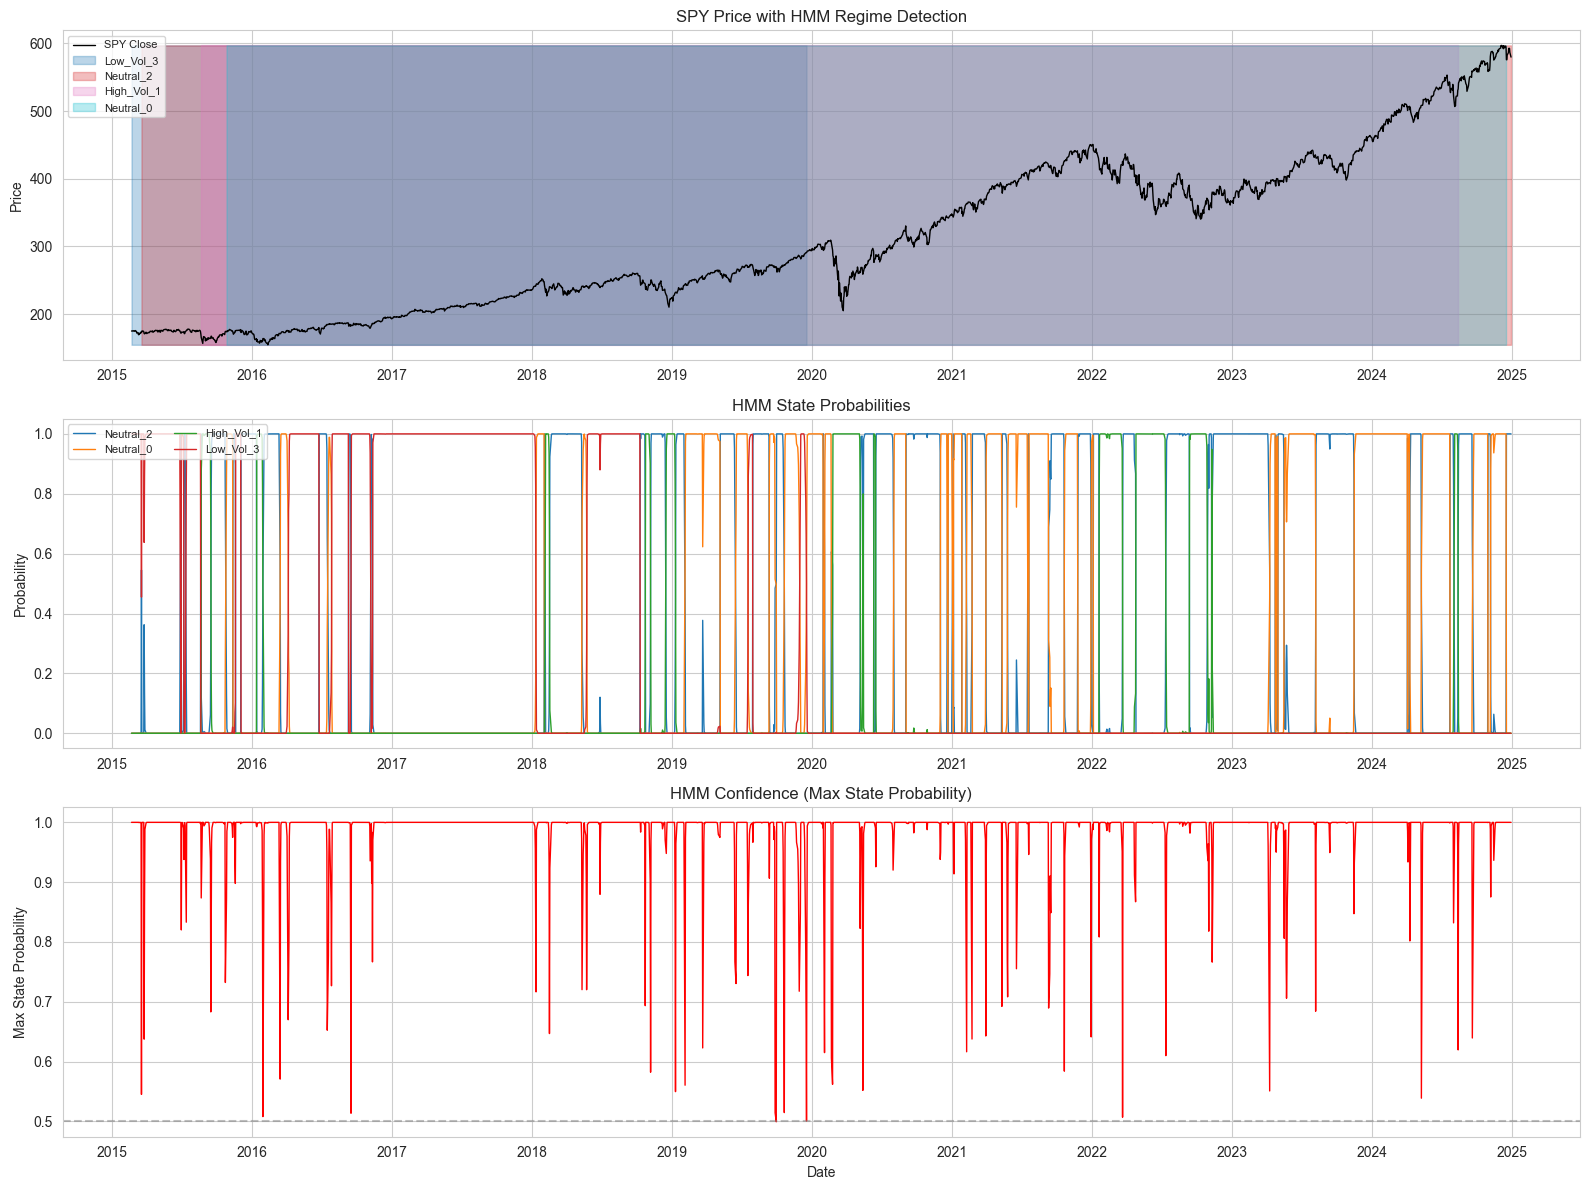

In [9]:
# Visualize HMM regimes
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Price with HMM regimes
ax1 = axes[0]
ax1.plot(df_aligned.index, df_aligned["Close"], label="SPY Close", linewidth=1, color="black")

# Get unique HMM regime labels
hmm_unique = hmm_regimes.unique()
hmm_colors = plt.cm.tab10(np.linspace(0, 1, len(hmm_unique)))
hmm_color_map = {regime: hmm_colors[i] for i, regime in enumerate(hmm_unique)}

for regime in hmm_unique:
    mask = hmm_regimes == regime
    ax1.fill_between(
        df_aligned.index[mask],
        df_aligned["Close"].min(),
        df_aligned["Close"].max(),
        alpha=0.3,
        label=f"{regime}",
        color=hmm_color_map[regime],
    )

ax1.set_ylabel("Price")
ax1.set_title("SPY Price with HMM Regime Detection")
ax1.legend(loc="upper left", fontsize=8)

# HMM state probabilities
ax2 = axes[1]
for col in hmm_probs.columns:
    ax2.plot(hmm_probs.index, hmm_probs[col], label=col, linewidth=1)
ax2.set_ylabel("Probability")
ax2.set_title("HMM State Probabilities")
ax2.legend(loc="upper left", fontsize=8, ncol=2)

# Dominant state probability (max prob)
ax3 = axes[2]
max_prob = hmm_probs.max(axis=1)
ax3.plot(hmm_probs.index, max_prob, linewidth=1, color="red")
ax3.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax3.set_ylabel("Max State Probability")
ax3.set_xlabel("Date")
ax3.set_title("HMM Confidence (Max State Probability)")

plt.tight_layout()
plt.show()

## 5. PCA + k-means Regime Detector

In [10]:
from src.ml.pca_kmeans_regime import PCAKMeansRegimeDetector

# Initialize and fit PCA + k-means
print("Fitting PCA + k-means regime detector...")
pca_detector = PCAKMeansRegimeDetector(
    k_range=CONFIG["pca_kmeans"]["k_range"],
    variance_threshold=CONFIG["pca_kmeans"]["variance_threshold"],
    random_state=CONFIG["pca_kmeans"]["random_state"],
)

pca_detector.fit(features_aligned)
pca_regimes = pca_detector.predict(features_aligned)
pca_probs = pca_detector.predict_proba(features_aligned)

print("PCA + k-means fitted successfully")
print(f"Optimal k: {pca_detector.optimal_k_}")
print("\nPCA info:")
pca_info = pca_detector.get_pca_info()
print(f"  Components: {pca_info['n_components']}")
print(f"  Explained variance: {pca_info['explained_variance_ratio']:.2%}")
print(f"\nRegime distribution:\n{pca_regimes.value_counts()}")

Fitting PCA + k-means regime detector...


PCA + k-means fitted successfully
Optimal k: 3

PCA info:
  Components: 11
  Explained variance: 100.00%

Regime distribution:
pca_kmeans_regime
Low_Vol_0     1871
Neutral_1      587
High_Vol_2      24
Name: count, dtype: int64


In [11]:
print("=" * 60)
print("SILHOUETTE SCORE ANALYSIS")
print("=" * 60)
print(pca_detector.get_silhouette_analysis())

print("\n" + "=" * 60)
print("CLUSTER CENTERS (PCA SPACE)")
print("=" * 60)
print(pca_detector.get_cluster_centers())

print("\n" + "=" * 60)
print("REGIME VOLATILITY")
print("=" * 60)
print(pca_detector.get_regime_volatility())

SILHOUETTE SCORE ANALYSIS
   silhouette_score
k                  
3          0.351745
4          0.188561
5          0.206703
6          0.214596

CLUSTER CENTERS (PCA SPACE)
                  PC1       PC2       PC3       PC4       PC5       PC6  \
Low_Vol_0    1.024933  0.090347 -0.032007 -0.039094  0.005885 -0.029503   
Neutral_1   -2.761837 -0.469564  0.064806  0.085652  0.007887  0.129187   
High_Vol_2 -12.352181  4.441474  0.910162  0.952810 -0.651731 -0.859702   

                 PC7       PC8       PC9      PC10      PC11  
Low_Vol_0   0.026277  0.051308  0.003469 -0.005496 -0.001523  
Neutral_1  -0.118627 -0.242726  0.001987  0.038581  0.015763  
High_Vol_2  0.852898  1.936793 -0.319011 -0.515194 -0.266809  

REGIME VOLATILITY
            distance_from_origin  volatility_rank
regime                                           
Low_Vol_0               1.032219                3
Neutral_1               2.819796                2
High_Vol_2             13.420884                1


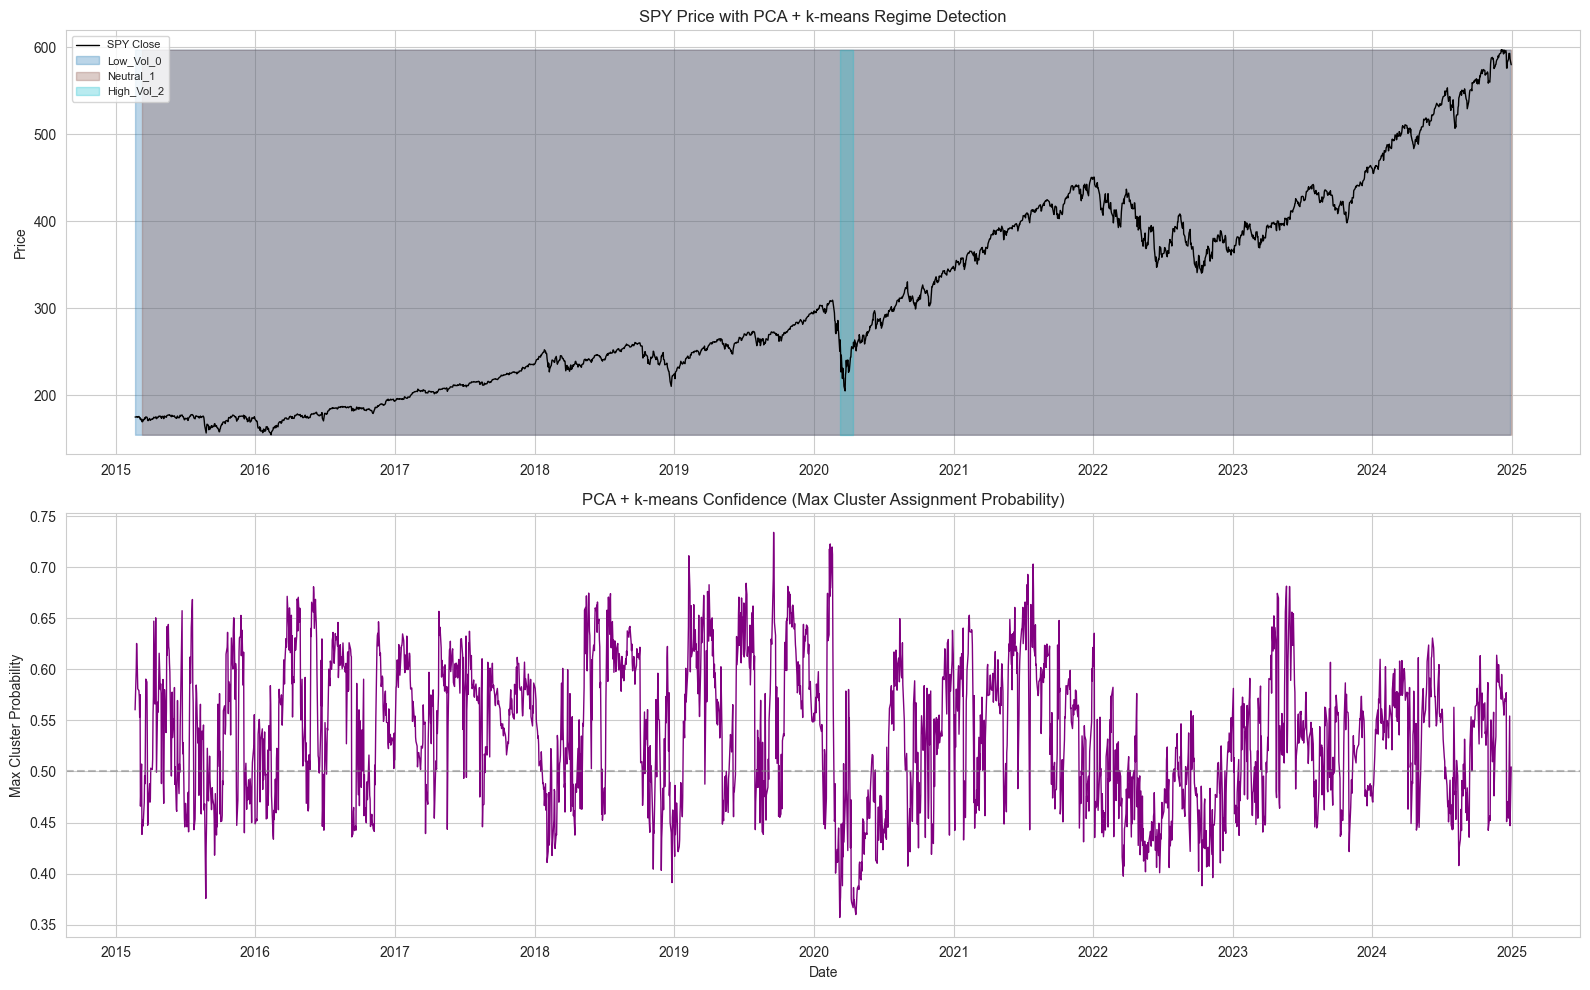

In [12]:
# Visualize PCA + k-means regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Price with PCA regimes
ax1 = axes[0]
ax1.plot(df_aligned.index, df_aligned["Close"], label="SPY Close", linewidth=1, color="black")

# Get unique PCA regime labels
pca_unique = pca_regimes.unique()
pca_colors = plt.cm.tab10(np.linspace(0, 1, len(pca_unique)))
pca_color_map = {regime: pca_colors[i] for i, regime in enumerate(pca_unique)}

for regime in pca_unique:
    mask = pca_regimes == regime
    ax1.fill_between(
        df_aligned.index[mask],
        df_aligned["Close"].min(),
        df_aligned["Close"].max(),
        alpha=0.3,
        label=f"{regime}",
        color=pca_color_map[regime],
    )

ax1.set_ylabel("Price")
ax1.set_title("SPY Price with PCA + k-means Regime Detection")
ax1.legend(loc="upper left", fontsize=8)

# Max cluster probability
ax2 = axes[1]
max_proba = pca_probs.max(axis=1)
ax2.plot(pca_probs.index, max_proba, linewidth=1, color="purple")
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Max Cluster Probability")
ax2.set_xlabel("Date")
ax2.set_title("PCA + k-means Confidence (Max Cluster Assignment Probability)")

plt.tight_layout()
plt.show()

## 6. Regime Comparison

In [13]:
# Create aligned comparison DataFrame
comparison = pd.DataFrame(index=df_aligned.index)
comparison["Close"] = df_aligned["Close"]
comparison["Rule-based"] = rule_regimes_aligned
comparison["HMM"] = hmm_regimes
comparison["PCA-kmeans"] = pca_regimes

# Check for agreement
print("=" * 60)
print("REGIME AGREEMENT MATRIX")
print("=" * 60)
print(f"\nTotal observations: {len(comparison)}")
print(
    f"\nAll three agree: {(comparison['Rule-based'] == comparison['HMM']) & (comparison['HMM'] == comparison['PCA-kmeans'])}"
)

REGIME AGREEMENT MATRIX

Total observations: 2482

All three agree: date
2015-02-20    False
2015-02-23    False
2015-02-24    False
2015-02-25    False
2015-02-26    False
              ...  
2024-12-23    False
2024-12-24    False
2024-12-26    False
2024-12-27    False
2024-12-30    False
Length: 2482, dtype: bool


C:\Users\Joey Chiu\AppData\Local\Temp\ipykernel_42160\1322198789.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right", fontsize=8)
C:\Users\Joey Chiu\AppData\Local\Temp\ipykernel_42160\1322198789.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc="upper right", fontsize=8)


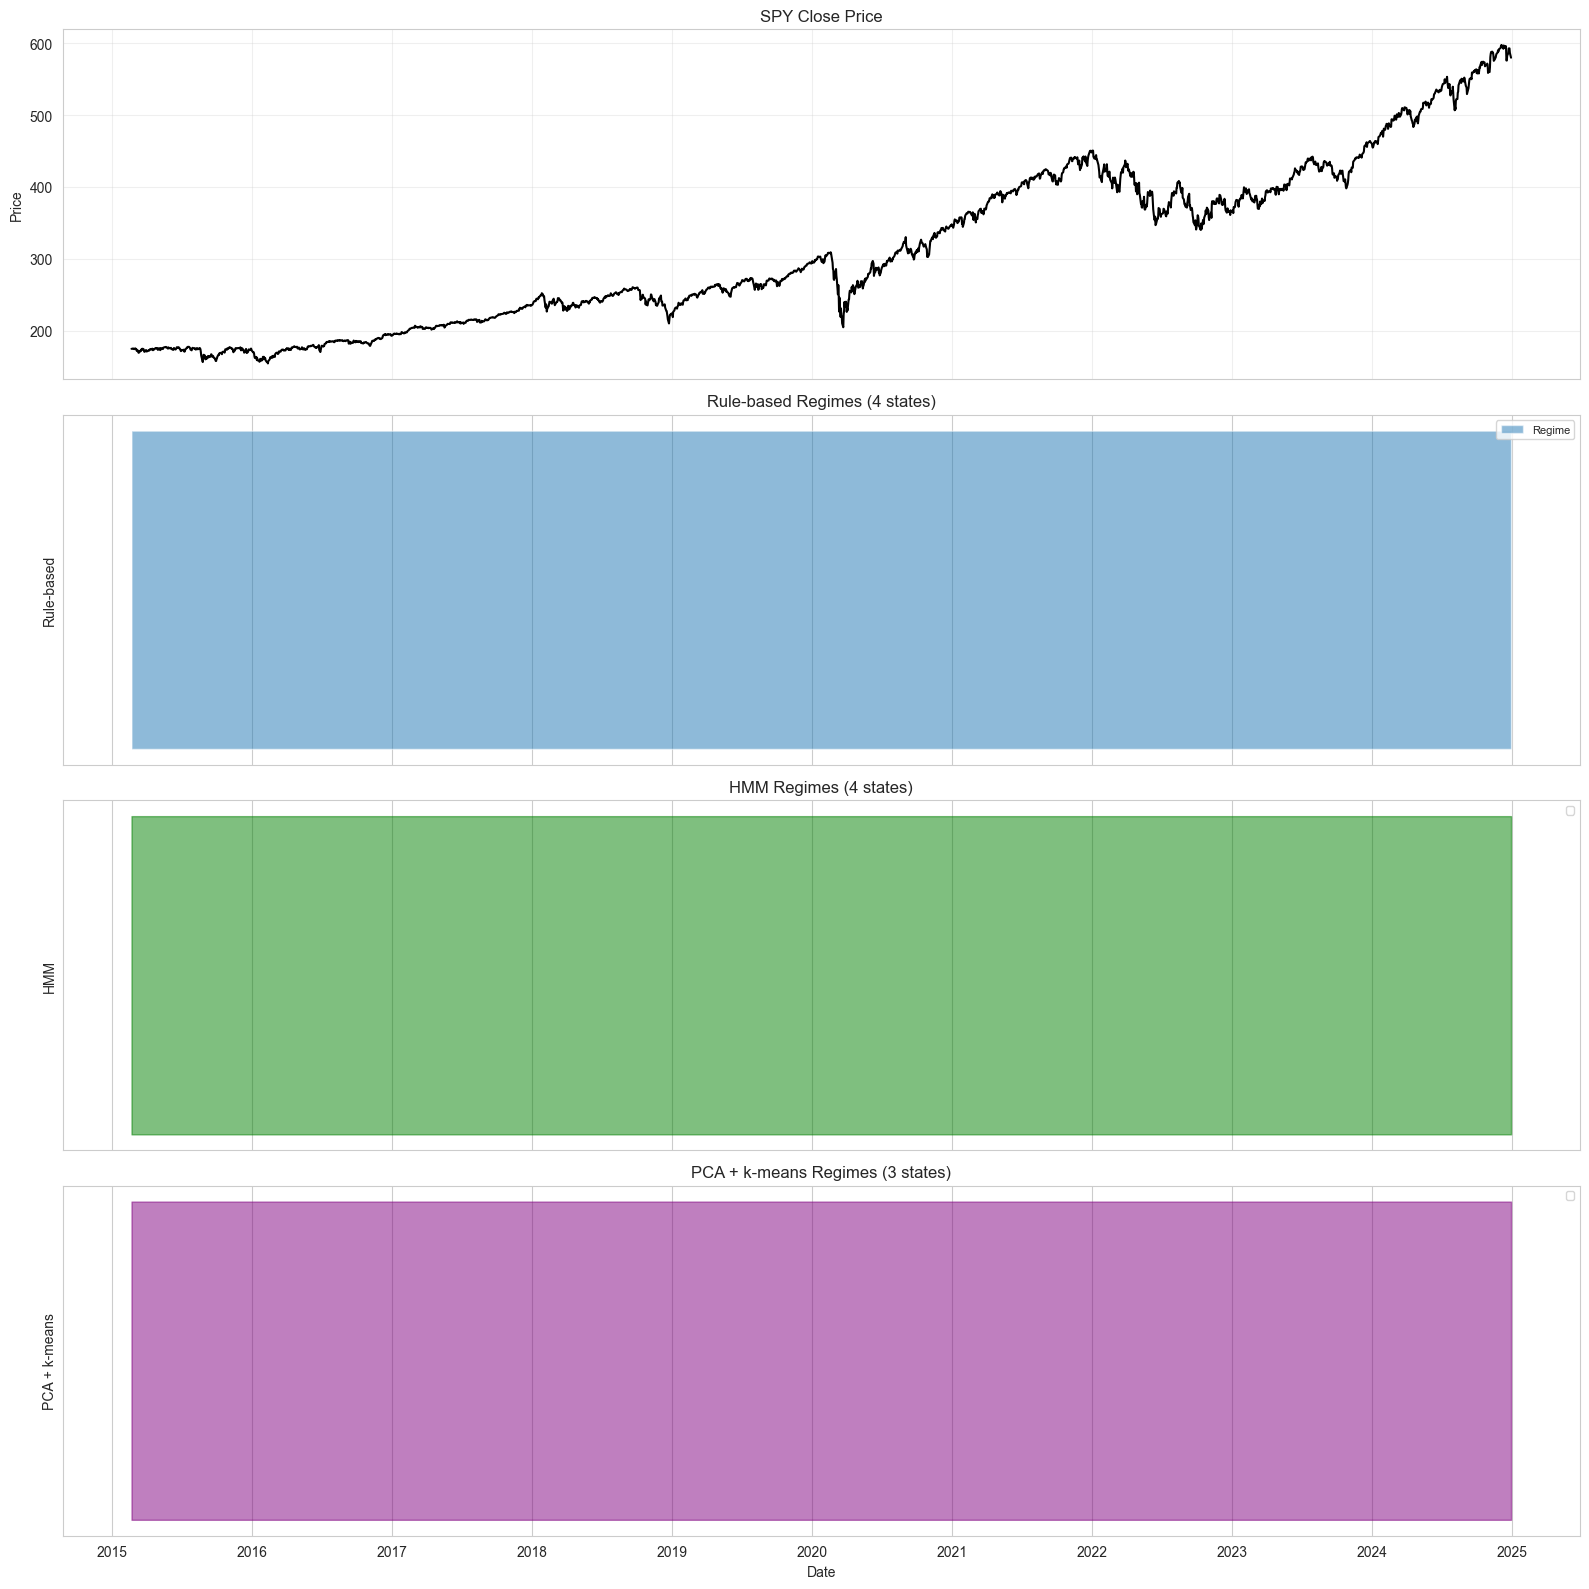

In [14]:
# Visualize all three regime detectors
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# Price
ax0 = axes[0]
ax0.plot(comparison.index, comparison["Close"], linewidth=1.5, color="black")
ax0.set_ylabel("Price")
ax0.set_title("SPY Close Price")
ax0.grid(True, alpha=0.3)

# Rule-based regimes
ax1 = axes[1]
rule_codes = pd.Categorical(comparison["Rule-based"]).codes
ax1.fill_between(comparison.index, 0, 1, where=rule_codes >= 0, alpha=0.5, label="Regime")
ax1.set_ylabel("Rule-based")
ax1.set_title(f"Rule-based Regimes ({len(comparison['Rule-based'].unique())} states)")
ax1.set_yticks([])
ax1.legend(loc="upper right", fontsize=8)

# HMM regimes
ax2 = axes[2]
hmm_codes = pd.Categorical(comparison["HMM"]).codes
ax2.fill_between(comparison.index, 0, 1, color="green", alpha=0.5, where=hmm_codes >= 0)
ax2.set_ylabel("HMM")
ax2.set_title(f"HMM Regimes ({len(comparison['HMM'].unique())} states)")
ax2.set_yticks([])
ax2.legend(loc="upper right", fontsize=8)

# PCA regimes
ax3 = axes[3]
pca_codes = pd.Categorical(comparison["PCA-kmeans"]).codes
ax3.fill_between(comparison.index, 0, 1, color="purple", alpha=0.5, where=pca_codes >= 0)
ax3.set_ylabel("PCA + k-means")
ax3.set_xlabel("Date")
ax3.set_title(f"PCA + k-means Regimes ({len(comparison['PCA-kmeans'].unique())} states)")
ax3.set_yticks([])
ax3.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

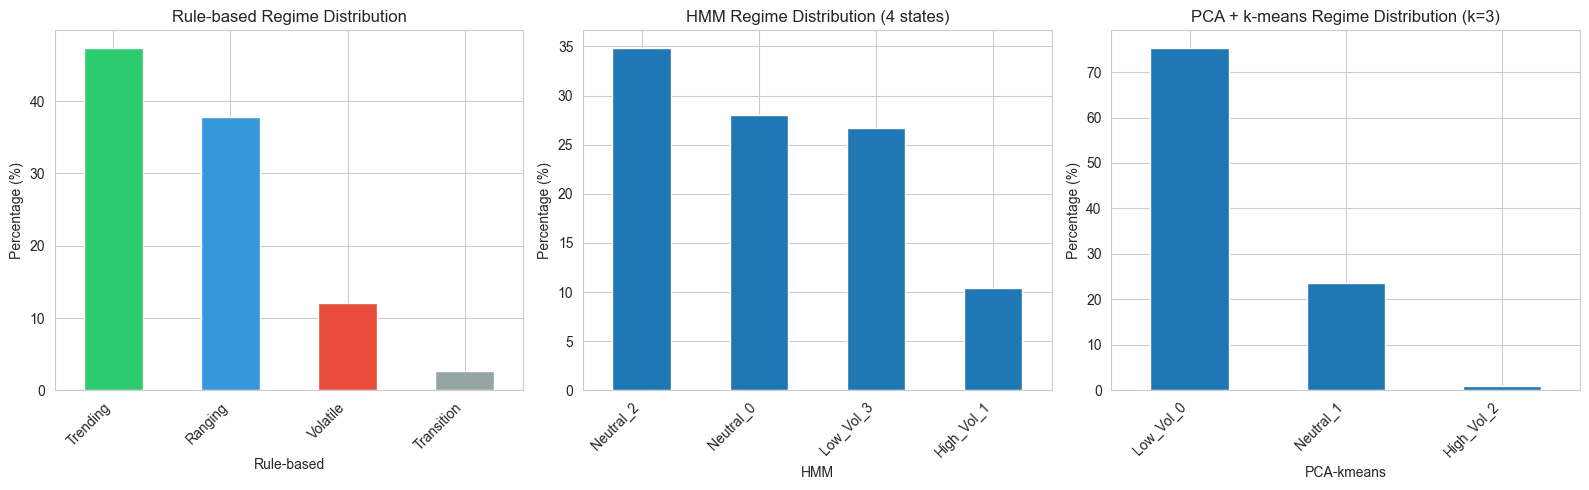


Distribution Statistics:
Detector             N Regimes    Top Regime                %
--------------------------------------------------------------
Rule-based           4            Trending                  47.4%
HMM                  4            Neutral_2                 34.9%
PCA + k-means        3            Low_Vol_0                 75.4%


In [15]:
# Regime distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rule-based
ax1 = axes[0]
rule_dist = comparison["Rule-based"].value_counts(normalize=True) * 100
rule_dist.plot(kind="bar", ax=ax1, color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"])
ax1.set_ylabel("Percentage (%)")
ax1.set_title("Rule-based Regime Distribution")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# HMM
ax2 = axes[1]
hmm_dist = comparison["HMM"].value_counts(normalize=True) * 100
hmm_dist.plot(kind="bar", ax=ax2, colormap="tab10")
ax2.set_ylabel("Percentage (%)")
ax2.set_title(f"HMM Regime Distribution ({CONFIG['hmm']['n_states']} states)")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

# PCA-kmeans
ax3 = axes[2]
pca_dist = comparison["PCA-kmeans"].value_counts(normalize=True) * 100
pca_dist.plot(kind="bar", ax=ax3, colormap="tab10")
ax3.set_ylabel("Percentage (%)")
ax3.set_title(f"PCA + k-means Regime Distribution (k={pca_detector.optimal_k_})")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

print("\nDistribution Statistics:")
print(f"{'Detector':<20} {'N Regimes':<12} {'Top Regime':<25} {'%'}")
print("-" * 62)
print(f"{'Rule-based':<20} {len(rule_dist):<12} {rule_dist.index[0]:<25} {rule_dist.iloc[0]:.1f}%")
print(f"{'HMM':<20} {len(hmm_dist):<12} {hmm_dist.index[0]:<25} {hmm_dist.iloc[0]:.1f}%")
print(f"{'PCA + k-means':<20} {len(pca_dist):<12} {pca_dist.index[0]:<25} {pca_dist.iloc[0]:.1f}%")

## 7. Detailed Regime Analysis

In [16]:
def analyze_regime_characteristics(comparison_df: pd.DataFrame) -> pd.DataFrame:
    """Analyze return characteristics during each regime."""
    results = []

    returns = comparison_df["Close"].pct_change()

    for detector in ["Rule-based", "HMM", "PCA-kmeans"]:
        for regime in comparison_df[detector].unique():
            mask = comparison_df[detector] == regime
            regime_returns = returns[mask]

            results.append(
                {
                    "detector": detector,
                    "regime": regime,
                    "n_days": mask.sum(),
                    "pct_days": (mask.sum() / len(comparison_df)) * 100,
                    "mean_return": regime_returns.mean(),
                    "std_return": regime_returns.std(),
                    "sharpe": regime_returns.mean() / regime_returns.std() * np.sqrt(252)
                    if regime_returns.std() > 0
                    else np.nan,
                    "skew": regime_returns.skew(),
                    "kurtosis": regime_returns.kurtosis(),
                }
            )

    return pd.DataFrame(results)


regime_stats = analyze_regime_characteristics(comparison)

# Display as formatted table
display_cols = [
    "detector",
    "regime",
    "n_days",
    "pct_days",
    "mean_return",
    "std_return",
    "sharpe",
    "skew",
]
regime_stats_display = regime_stats[display_cols].copy()
regime_stats_display["mean_return"] = (regime_stats_display["mean_return"] * 100).round(3)
regime_stats_display["std_return"] = (regime_stats_display["std_return"] * 100).round(3)
regime_stats_display["sharpe"] = regime_stats_display["sharpe"].round(2)
regime_stats_display["skew"] = regime_stats_display["skew"].round(2)
regime_stats_display = regime_stats_display.sort_values(
    ["detector", "sharpe"], ascending=[True, False]
)

print("Regime Return Characteristics:")
print("=" * 90)
for detector in regime_stats["detector"].unique():
    detector_stats = regime_stats_display[regime_stats_display["detector"] == detector]
    print(f"\n{detector}:")
    print(detector_stats.to_string(index=False))

Regime Return Characteristics:

Rule-based:
  detector     regime  n_days  pct_days  mean_return  std_return  sharpe  skew
Rule-based   Trending    1177 47.421434        0.074       1.310    0.89 -0.45
Rule-based    Ranging     938 37.792103        0.042       0.854    0.79 -0.84
Rule-based Transition      67  2.699436        0.020       0.692    0.45 -0.14
Rule-based   Volatile     300 12.087027        0.025       1.056    0.38 -0.82

HMM:
detector     regime  n_days  pct_days  mean_return  std_return  sharpe  skew
     HMM  Neutral_0     695 28.001612        0.143       0.553    4.11 -0.07
     HMM  Low_Vol_3     662 26.672039        0.054       0.504    1.71 -0.14
     HMM  Neutral_2     866 34.891217        0.029       1.133    0.41 -0.30
     HMM High_Vol_1     259 10.435133       -0.097       2.463   -0.63 -0.20

PCA-kmeans:
  detector     regime  n_days  pct_days  mean_return  std_return  sharpe  skew
PCA-kmeans  Low_Vol_0    1871 75.382756        0.164       0.692    3.75  0.46

## 8. Transition Analysis

In [17]:
def calculate_transition_matrix(regimes: pd.Series) -> pd.DataFrame:
    """Calculate regime transition matrix."""
    n = len(regimes)
    unique = regimes.unique()
    n_regimes = len(unique)

    trans = pd.DataFrame(np.zeros((n_regimes, n_regimes)), index=unique, columns=unique)

    for i in range(n - 1):
        current = regimes.iloc[i]
        next_regime = regimes.iloc[i + 1]
        trans.loc[current, next_regime] += 1

    # Convert to probabilities
    row_sums = trans.sum(axis=1, skipna=True)
    trans_prob = trans.div(row_sums, axis=0)

    return trans_prob


# Calculate transition matrices
print("=" * 60)
print("TRANSITION MATRICES")
print("=" * 60)

for detector in ["Rule-based", "HMM"]:
    trans = calculate_transition_matrix(comparison[detector])
    print(f"\n{detector}:")
    print((trans * 100).round(1).astype(str) + "%")

TRANSITION MATRICES



Rule-based:
           Transition Ranging Volatile Trending
Transition      98.5%    1.5%     0.0%     0.0%
Ranging          0.0%   97.9%     0.7%     1.4%
Volatile         0.0%    2.0%    92.7%     5.3%
Trending         0.0%    1.1%     1.3%    97.6%



HMM:
           Low_Vol_3 Neutral_2 High_Vol_1 Neutral_0
Low_Vol_3      98.2%      1.5%       0.0%      0.3%
Neutral_2       0.7%     94.7%       1.5%      3.1%
High_Vol_1      0.0%      5.0%      95.0%      0.0%
Neutral_0       0.7%      3.5%       0.0%     95.8%


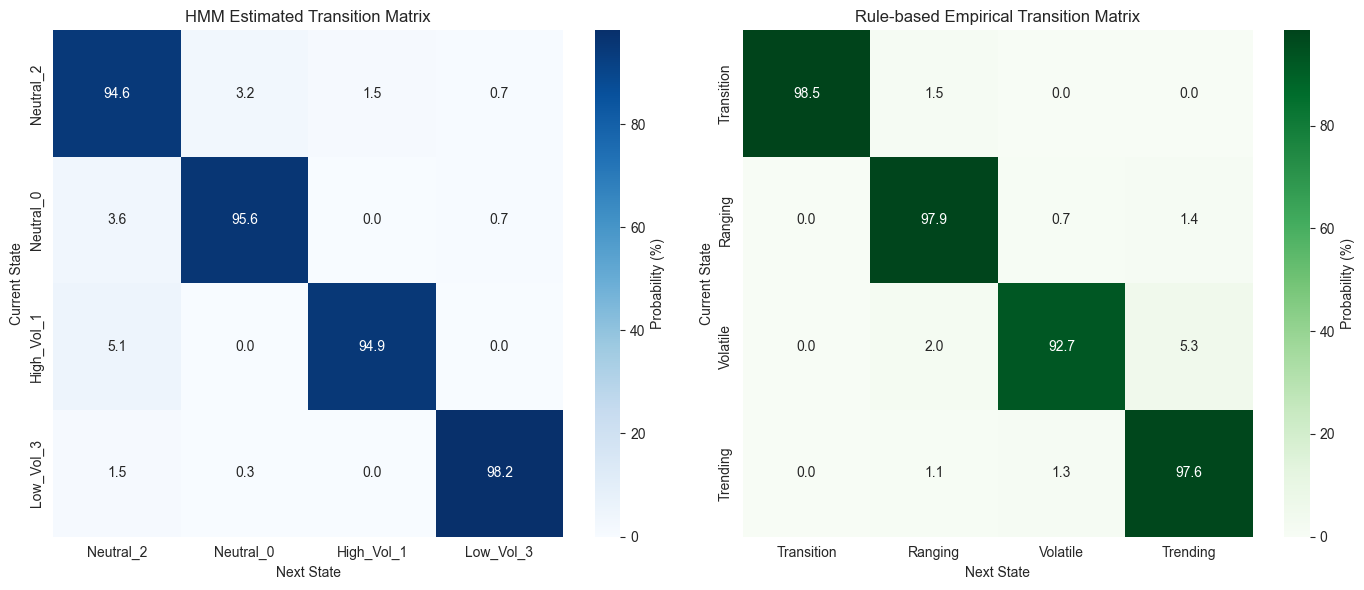

In [18]:
# Visualize transition matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HMM transition matrix (from model)
ax1 = axes[0]
hmm_transmat = hmm_detector.get_transition_matrix()
sns.heatmap(
    hmm_transmat * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=ax1,
    cbar_kws={"label": "Probability (%)"},
)
ax1.set_title("HMM Estimated Transition Matrix")
ax1.set_xlabel("Next State")
ax1.set_ylabel("Current State")

# Rule-based empirical transition matrix
ax2 = axes[1]
rule_transmat = calculate_transition_matrix(comparison["Rule-based"])
sns.heatmap(
    rule_transmat * 100,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    ax=ax2,
    cbar_kws={"label": "Probability (%)"},
)
ax2.set_title("Rule-based Empirical Transition Matrix")
ax2.set_xlabel("Next State")
ax2.set_ylabel("Current State")

plt.tight_layout()
plt.show()

## 9. Key Period Comparison

In [19]:
# Find periods where detectors disagree
comparison["All_agree"] = (comparison["Rule-based"] == comparison["HMM"]) & (
    comparison["HMM"] == comparison["PCA-kmeans"]
)

disagreement = comparison[~comparison["All_agree"]]
agreement = comparison[comparison["All_agree"]]

print("AGREEMENT ANALYSIS")
print("=" * 60)
print(f"Total days: {len(comparison)}")
print(f"Days all agree: {len(agreement)} ({len(agreement) / len(comparison) * 100:.1f}%)")
print(f"Days disagreement: {len(disagreement)} ({len(disagreement) / len(comparison) * 100:.1f}%)")

# Show sample disagreement periods
print("\nSample disagreement periods:")
print(disagreement[["Rule-based", "HMM", "PCA-kmeans"]].head(20))

AGREEMENT ANALYSIS
Total days: 2482
Days all agree: 0 (0.0%)
Days disagreement: 2482 (100.0%)

Sample disagreement periods:
            Rule-based        HMM PCA-kmeans
date                                        
2015-02-20  Transition  Low_Vol_3  Low_Vol_0
2015-02-23  Transition  Low_Vol_3  Low_Vol_0
2015-02-24  Transition  Low_Vol_3  Low_Vol_0
2015-02-25  Transition  Low_Vol_3  Low_Vol_0
2015-02-26  Transition  Low_Vol_3  Low_Vol_0
2015-02-27  Transition  Low_Vol_3  Low_Vol_0
2015-03-02  Transition  Low_Vol_3  Low_Vol_0
2015-03-03  Transition  Low_Vol_3  Low_Vol_0
2015-03-04  Transition  Low_Vol_3  Low_Vol_0
2015-03-05  Transition  Low_Vol_3  Low_Vol_0
2015-03-06  Transition  Low_Vol_3  Low_Vol_0
2015-03-09  Transition  Low_Vol_3  Low_Vol_0
2015-03-10  Transition  Low_Vol_3  Neutral_1
2015-03-11  Transition  Low_Vol_3  Low_Vol_0
2015-03-12  Transition  Low_Vol_3  Low_Vol_0
2015-03-13  Transition  Low_Vol_3  Neutral_1
2015-03-16  Transition  Low_Vol_3  Low_Vol_0
2015-03-17  Transitio

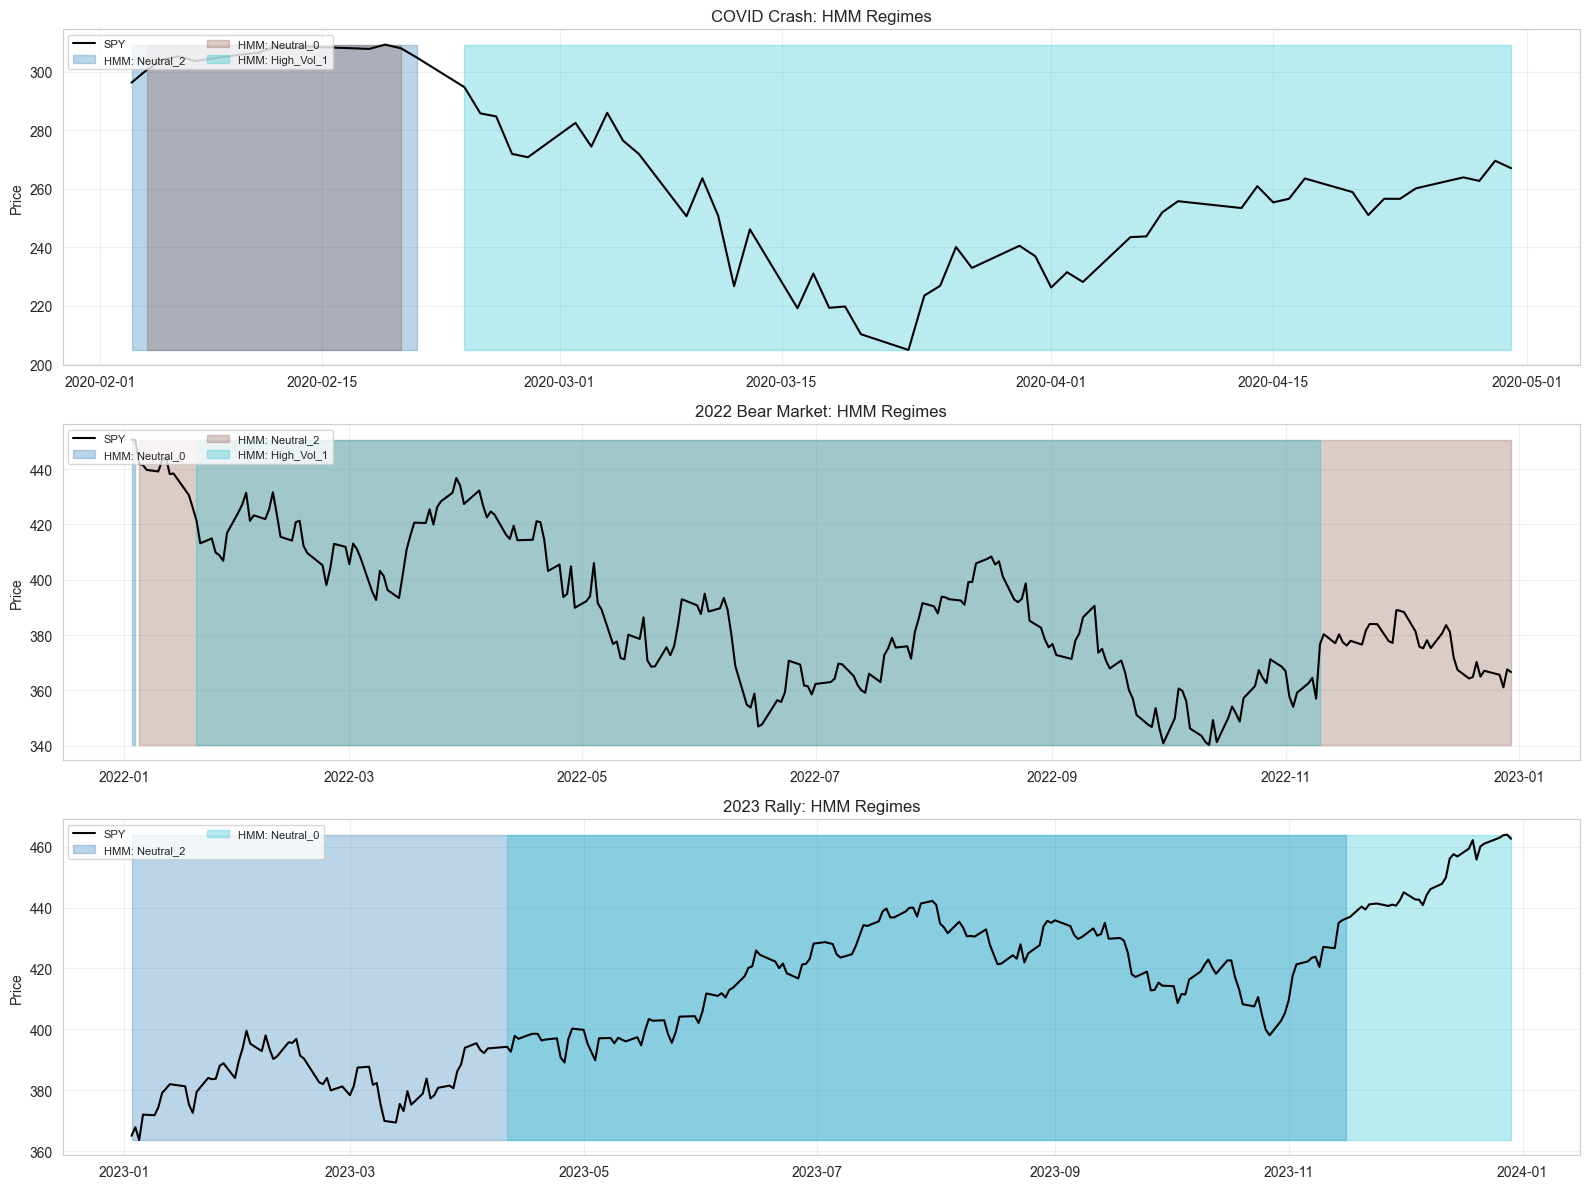

In [20]:
# Zoom into specific periods to compare detectors
periods_of_interest = [
    ("COVID Crash", "2020-02-01", "2020-04-30"),
    ("2022 Bear Market", "2022-01-01", "2022-12-31"),
    ("2023 Rally", "2023-01-01", "2023-12-31"),
]

fig, axes = plt.subplots(len(periods_of_interest), 1, figsize=(16, 4 * len(periods_of_interest)))
if len(periods_of_interest) == 1:
    axes = [axes]

for idx, (name, start, end) in enumerate(periods_of_interest):
    ax = axes[idx]
    mask = (comparison.index >= start) & (comparison.index <= end)
    period = comparison[mask]

    # Price line
    ax.plot(period.index, period["Close"], label="SPY", color="black", linewidth=1.5)

    # Regime backgrounds
    unique_regimes = period["HMM"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_regimes)))

    for regime, color in zip(unique_regimes, colors):
        regime_mask = period["HMM"] == regime
        ax.fill_between(
            period.index[regime_mask],
            period["Close"].min(),
            period["Close"].max(),
            alpha=0.3,
            color=color,
            label=f"HMM: {regime}",
        )

    ax.set_ylabel("Price")
    ax.set_title(f"{name}: HMM Regimes")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary & Recommendations

In [21]:
# Create summary table
summary = pd.DataFrame(
    {
        "Detector": ["Rule-based", "HMM", "PCA + k-means"],
        "N Regimes": [
            len(comparison["Rule-based"].unique()),
            len(comparison["HMM"].unique()),
            len(comparison["PCA-kmeans"].unique()),
        ],
        "Avg Daily Return (%)": [
            comparison.groupby("Rule-based")["Close"].pct_change().mean().mean() * 100,
            comparison.groupby("HMM")["Close"].pct_change().mean().mean() * 100,
            comparison.groupby("PCA-kmeans")["Close"].pct_change().mean().mean() * 100,
        ],
        "Avg Volatility (%)": [
            comparison.groupby("Rule-based")["Close"].pct_change().std().mean() * 100,
            comparison.groupby("HMM")["Close"].pct_change().std().mean() * 100,
            comparison.groupby("PCA-kmeans")["Close"].pct_change().std().mean() * 100,
        ],
        "Methodology": ["ADX/ATR thresholds", "Gaussian HMM", "PCA + k-means clustering"],
        "Pros": [
            "Interpretable, fast",
            "Probabilistic, captures dynamics",
            "Data-driven, no assumptions",
        ],
        "Cons": [
            "Fixed thresholds, may not adapt",
            "Assumes Markov property, Gaussian",
            "Less interpretable, sensitive to k",
        ],
    }
).set_index("Detector")

print("REGIME DETECTOR COMPARISON SUMMARY")
print("=" * 90)
print(summary.to_string())

REGIME DETECTOR COMPARISON SUMMARY
               N Regimes  Avg Daily Return (%)  Avg Volatility (%)               Methodology                              Pros                                Cons
Detector                                                                                                                                                          
Rule-based             4              0.169589            2.008233        ADX/ATR thresholds               Interpretable, fast     Fixed thresholds, may not adapt
HMM                    4              0.186967            2.208927              Gaussian HMM  Probabilistic, captures dynamics   Assumes Markov property, Gaussian
PCA + k-means          3              0.108291            1.554529  PCA + k-means clustering       Data-driven, no assumptions  Less interpretable, sensitive to k


In [22]:
# Final recommendations
print("\n" + "=" * 90)
print("KEY FINDINGS & RECOMMENDATIONS")
print("=" * 90)
print("""
1. STRENGTHS BY DETECTOR:
   - Rule-based: Fast, interpretable, works well in clear trending/ranging markets
   - HMM: Captures regime dynamics, provides transition probabilities
   - PCA+k-means: Purely data-driven, adapts to changing market structure

2. WHEN TO USE EACH:
   - Rule-based: Baseline, quick analysis, regulatory/compliance needs
   - HMM: When regime transitions are important (position sizing, risk management)
   - PCA+k-means: Exploratory analysis, detecting novel regimes

3. ENSEMBLE RECOMMENDATION:
   Consider combining detectors via:
   a) Voting: Use majority vote across detectors
   b) Confidence weighting: Weight by detector confidence (HMM probas, silhouette)
   c) Hierarchical: Use rule-based as primary, ML for ambiguous periods

4. FURTHER VALIDATION NEEDED:
   - Walk-forward testing on unseen data
   - Economic significance: Do regimes predict returns/volatility?
   - Strategy integration: Test with actual trading rules per regime
""")


KEY FINDINGS & RECOMMENDATIONS

1. STRENGTHS BY DETECTOR:
   - Rule-based: Fast, interpretable, works well in clear trending/ranging markets
   - HMM: Captures regime dynamics, provides transition probabilities
   - PCA+k-means: Purely data-driven, adapts to changing market structure

2. WHEN TO USE EACH:
   - Rule-based: Baseline, quick analysis, regulatory/compliance needs
   - HMM: When regime transitions are important (position sizing, risk management)
   - PCA+k-means: Exploratory analysis, detecting novel regimes

3. ENSEMBLE RECOMMENDATION:
   Consider combining detectors via:
   a) Voting: Use majority vote across detectors
   b) Confidence weighting: Weight by detector confidence (HMM probas, silhouette)
   c) Hierarchical: Use rule-based as primary, ML for ambiguous periods

4. FURTHER VALIDATION NEEDED:
   - Walk-forward testing on unseen data
   - Economic significance: Do regimes predict returns/volatility?
   - Strategy integration: Test with actual trading rules per reg